### **KNN Classification on Wine Quality Dataset**

This notebook demonstrates K-Nearest Neighbors classification on the **Wine Quality dataset** from Kaggle.

**Dataset:** https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009

**Goal:** Predict whether a red wine is *good* (quality >= 7) or *not good* based on its physicochemical properties.

## Steps
1. Load the data
2. Explore it briefly
3. Preprocess (binary target + scaling)
4. Train/test split
5. Train KNN and evaluate
6. Tune `k` and visualize

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)

sns.set_style('whitegrid')

# Doownloads UCI Dataset which is the same as the one in Kaggle
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
df = pd.read_csv(url, sep=';')

print('Shape:', df.shape)
df.head()

Shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


#### **EDA**

In [2]:
print(df.info())
print('\nMissing values:', df.isnull().sum().sum())
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None

Missing values: 0


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


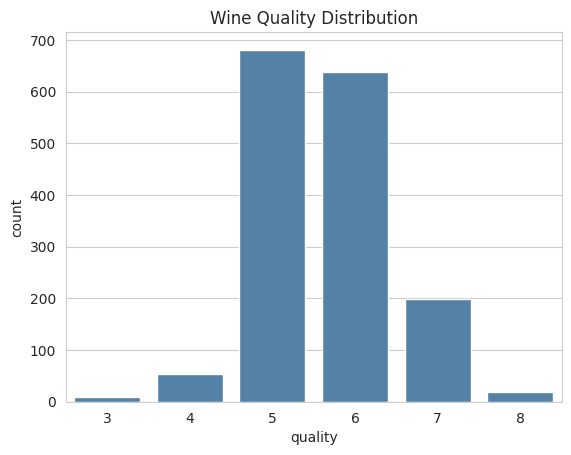

In [3]:
# Distribution of the quality score
sns.countplot(x='quality', data=df, color='steelblue')
plt.title('Wine Quality Distribution')
plt.show()

#### **Feature Engineering - Preprocessing**

We turn this into a binary classification: **good wine** (quality ≥ 7) vs **not good**. KNN is distance-based, so we **scale** the features.

In [4]:
# Binary target
df['good_quality'] = (df['quality'] >= 7).astype(int)

X = df.drop(columns=['quality', 'good_quality'])
y = df['good_quality']

print('Class balance:')
print(y.value_counts(normalize=True).round(3))

Class balance:
good_quality
0    0.864
1    0.136
Name: proportion, dtype: float64


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}')

Train: (1279, 11), Test: (320, 11)


#### **Train a Baseline KNN (k=5)**

In [6]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}\n')
print('Classification report:\n', classification_report(y_test, y_pred))

Accuracy: 0.8938

Classification report:
               precision    recall  f1-score   support

           0       0.91      0.97      0.94       277
           1       0.67      0.42      0.51        43

    accuracy                           0.89       320
   macro avg       0.79      0.69      0.73       320
weighted avg       0.88      0.89      0.88       320



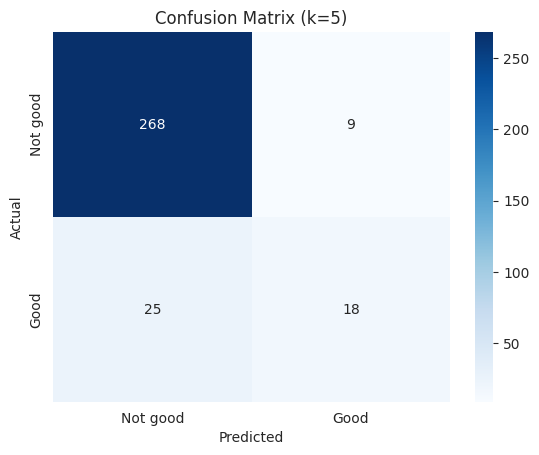

In [7]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not good', 'Good'],
            yticklabels=['Not good', 'Good'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (k=5)')
plt.show()

#### **Tune `k` with Cross-Validation**

Best k: 2 with CV accuracy 0.8788


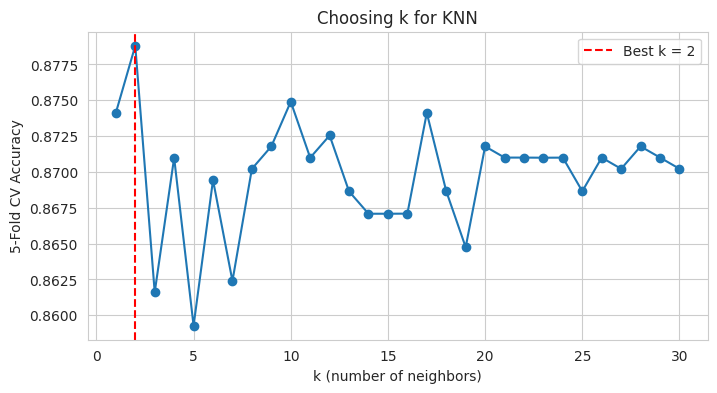

In [8]:
k_values = range(1, 31)
cv_scores = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

best_k = k_values[int(np.argmax(cv_scores))]
print(f'Best k: {best_k} with CV accuracy {max(cv_scores):.4f}')

plt.figure(figsize=(8, 4))
plt.plot(list(k_values), cv_scores, marker='o')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k = {best_k}')
plt.xlabel('k (number of neighbors)')
plt.ylabel('5-Fold CV Accuracy')
plt.title('Choosing k for KNN')
plt.legend()
plt.show()

#### **Final Model with Best `k`**

In [9]:
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train)

y_pred_final = final_knn.predict(X_test_scaled)

print(f'Final test accuracy (k={best_k}): {accuracy_score(y_test, y_pred_final):.4f}\n')
print(classification_report(y_test, y_pred_final))

Final test accuracy (k=2): 0.9062

              precision    recall  f1-score   support

           0       0.92      0.98      0.95       277
           1       0.76      0.44      0.56        43

    accuracy                           0.91       320
   macro avg       0.84      0.71      0.75       320
weighted avg       0.90      0.91      0.90       320



#### **Next Steps**

- The dataset is **imbalanced** (~86% not good, ~14% good). Accuracy can be misleading; look at precision/recall for the *good* class.
- Things to try next:
  - Use `class_weight` via resampling (e.g. SMOTE) to handle imbalance
  - Try `weights='distance'` in `KNeighborsClassifier`
  - Compare against logistic regression or a random forest as baselines
  - Apply the same pipeline to `winequality-white.csv`